# **Day 51: Anomaly Detection**
*Module 8 - Unsupervised Learning*

Anomalies (outliers, novelties) are rare observations that differ from the normal pattern: fraudulent transactions, failing machines, sensor errors, sudden deforestation, unusual NDVI drops. Labels for anomalies are usually **rare or absent**, so most methods learn what **normal** looks like and flag deviations.

> Anomaly detection finds rare, unusual samples that do not fit the normal pattern, often without any labels. Isolation forests, one-class SVMs and reconstruction errors are common tools.
>
> *Example:* In a year of daily sensor readings, a sudden drop in soil moisture on one day may signal a faulty sensor or an unusual event.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.covariance import EllipticEnvelope, MinCovDet
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.preprocessing import StandardScaler
rng = np.random.default_rng(51)

## **1. Types of Anomalies**

| Type | Description | Example |
|---|---|---|
| Point | A single value far from the rest | A transaction of Rs 10 lakh on a student card |
| Contextual | Normal globally, abnormal in its context | 30 C in December in Shimla; low NDVI in the peak growing season |
| Collective | A sequence that is abnormal together | A flat-lined sensor; a sudden structured drop in a time series |

**Outlier detection**: training data contain anomalies (unsupervised). **Novelty detection**: train on clean normal data, detect new abnormal points (semi-supervised).

## **2. A Benchmark With Known Anomalies**
Normal data: two correlated clusters of different density. Anomalies: scattered uniformly, plus a few "local" anomalies near the dense cluster.

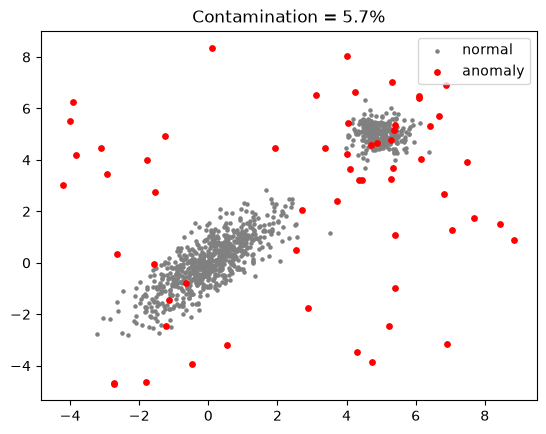

In [2]:
n_norm = 1000
normal = np.vstack([rng.multivariate_normal([0, 0], [[1, 0.8], [0.8, 1]], 700), rng.multivariate_normal([5, 5], [[0.15, 0], [0, 0.15]], 300)])
global_anom = rng.uniform(-5, 9, (40, 2))
local_anom = np.array([5, 5]) + rng.normal(0, 1.1, (20, 2))                     # just outside the tight cluster
X = np.vstack([normal, global_anom, local_anom])
y = np.r_[np.zeros(len(normal)), np.ones(len(global_anom) + len(local_anom))].astype(int)
plt.scatter(*X[y == 0].T, s=5, c="grey", label="normal"); plt.scatter(*X[y == 1].T, s=15, c="r", label="anomaly")
plt.legend(); plt.title(f"Contamination = {y.mean():.1%}"); plt.show()

## **3. Statistical Approach: (Robust) Mahalanobis Distance**
$D_M(\mathbf x) = \sqrt{(\mathbf x-\boldsymbol\mu)^\top\Sigma^{-1}(\mathbf x-\boldsymbol\mu)}$ accounts for correlation. But the mean and covariance are themselves distorted by anomalies, so use a **robust** estimate (Minimum Covariance Determinant, Rousseeuw 1984).

In [3]:
classical = np.sqrt(((X - X.mean(0)) @ np.linalg.inv(np.cov(X.T)) * (X - X.mean(0))).sum(1))
mcd = MinCovDet(random_state=0).fit(X)
robust = np.sqrt(mcd.mahalanobis(X))
print(f"classical Mahalanobis AUC {roc_auc_score(y, classical):.3f} | robust (MCD) {roc_auc_score(y, robust):.3f}")
print("A single Gaussian cannot describe two clusters well: both are limited here.")

classical Mahalanobis AUC 0.908 | robust (MCD) 0.887
A single Gaussian cannot describe two clusters well: both are limited here.


## **4. Isolation Forest**
Idea (Liu et al., 2008): anomalies are **few and different**, so they are **easy to isolate**. Build random trees that split on a random feature at a random threshold. Anomalies end up in leaves after **few** splits; normal points need many. The anomaly score is based on the average **path length**.

In [4]:
def isolation_tree_depth(x, X, depth=0, max_depth=12, r=None):
    if depth >= max_depth or len(X) <= 1:
        return depth + (2 * (np.log(len(X) - 1) + 0.5772) - 2 * (len(X) - 1) / len(X) if len(X) > 2 else 0)   # c(n) correction
    j = r.integers(X.shape[1]); lo, hi = X[:, j].min(), X[:, j].max()
    if lo == hi:
        return depth
    s = r.uniform(lo, hi)
    side = X[:, j] < s
    return isolation_tree_depth(x, X[side] if x[j] < s else X[~side], depth + 1, max_depth, r)

def iforest_scratch(X, n_trees=100, sample_size=256, seed=0):
    r = np.random.default_rng(seed); depths = np.zeros(len(X))
    for _ in range(n_trees):
        sub = X[r.choice(len(X), sample_size, replace=False)]
        depths += np.array([isolation_tree_depth(x, sub, r=r) for x in X])
    return -depths / n_trees                                                  # shorter paths = more anomalous = higher score

score_scratch = iforest_scratch(X, n_trees=50)
iso = IsolationForest(n_estimators=300, contamination="auto", random_state=0).fit(X)
score_iso = -iso.score_samples(X)
print(f"Isolation Forest AUC: scratch {roc_auc_score(y, score_scratch):.3f} | sklearn {roc_auc_score(y, score_iso):.3f}")

Isolation Forest AUC: scratch 0.940 | sklearn 0.944


## **5. Local Outlier Factor (LOF)**
Compares the local density of a point with the density of its neighbours. A point in a sparse region **next to a dense cluster** is anomalous even if it is close in absolute terms: LOF catches **local** anomalies that global methods miss.

## **6. One-Class SVM**
Learns a boundary enclosing most of the data in kernel space (Scholkopf et al., 2001). `nu` upper-bounds the fraction of training points treated as outliers. Sensitive to scaling and `gamma`.

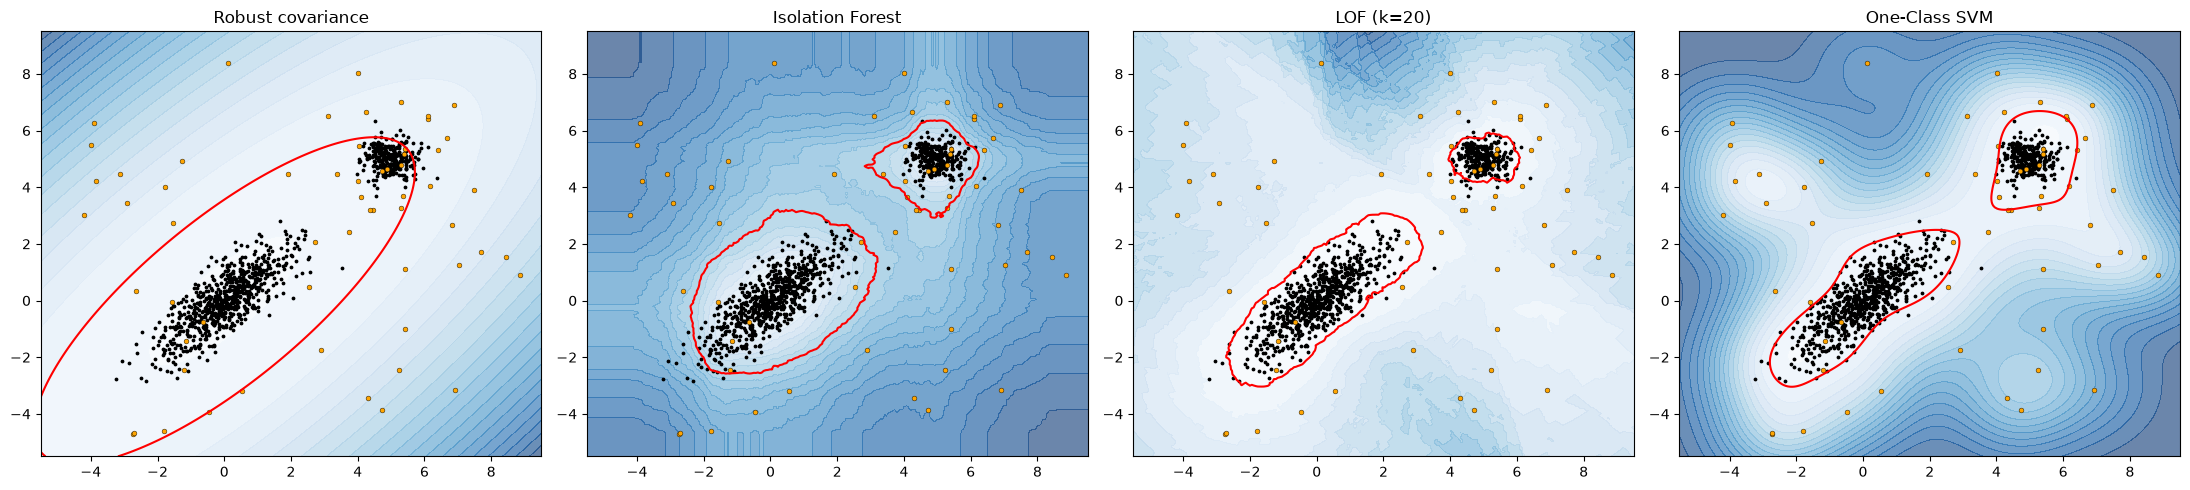

,ROC-AUC,PR-AUC,recall@flag,false alarm rate,local anomalies caught
detector,,,,,
Robust covariance,0.887,0.649,0.583,0.029,0.35
Isolation Forest,0.944,0.782,0.733,0.020,0.50
LOF (k=20),0.925,0.842,0.833,0.014,0.75
One-Class SVM,0.915,0.803,0.767,0.023,0.55


In [5]:
detectors = {"Robust covariance": EllipticEnvelope(contamination=0.06, random_state=0),
             "Isolation Forest": IsolationForest(n_estimators=300, contamination=0.06, random_state=0),
             "LOF (k=20)": LocalOutlierFactor(n_neighbors=20, contamination=0.06),
             "One-Class SVM": OneClassSVM(nu=0.06, gamma=0.3)}
xx, yy = np.meshgrid(np.linspace(-5.5, 9.5, 250), np.linspace(-5.5, 9.5, 250)); grid = np.c_[xx.ravel(), yy.ravel()]
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
rows = []
for ax, (name, det) in zip(axes, detectors.items()):
    if name.startswith("LOF"):
        pred = det.fit_predict(X); score = -det.negative_outlier_factor_
        lof_novel = LocalOutlierFactor(n_neighbors=20, novelty=True).fit(X); Zg = lof_novel.decision_function(grid)
    else:
        det.fit(X); pred = det.predict(X); score = -det.score_samples(X); Zg = det.decision_function(grid)
    ax.contourf(xx, yy, Zg.reshape(xx.shape), levels=20, cmap="Blues_r", alpha=0.6); ax.contour(xx, yy, Zg.reshape(xx.shape), levels=[0], colors="r")
    ax.scatter(*X[y == 0].T, s=3, c="k"); ax.scatter(*X[y == 1].T, s=12, c="orange", edgecolor="k", lw=0.3)
    rows.append({"detector": name, "ROC-AUC": roc_auc_score(y, score), "PR-AUC": average_precision_score(y, score),
                 "recall@flag": np.mean(pred[y == 1] == -1), "false alarm rate": np.mean(pred[y == 0] == -1),
                 "local anomalies caught": np.mean(pred[-20:] == -1)})
    ax.set_title(name)
plt.tight_layout(); plt.show()
pd.DataFrame(rows).set_index("detector").round(3)

LOF catches the **local** anomalies around the tight cluster best; Isolation Forest is a strong, fast default for global anomalies in many dimensions.

## **7. Choosing the Threshold**
`contamination` sets the threshold as a percentile of training scores. If we do not know the true rate:
- Inspect the score distribution for a natural gap.
- Use a small labelled validation set to pick a threshold that gives the needed precision or recall.
- Rank and review: send the top-N scores to a human expert (common in practice).

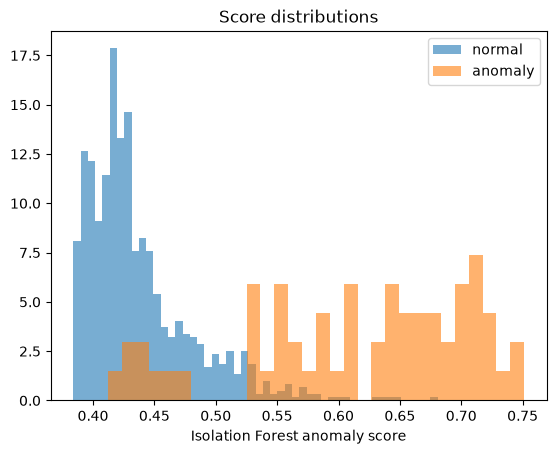

In [6]:
plt.hist(score_iso[y == 0], bins=50, alpha=0.6, label="normal", density=True); plt.hist(score_iso[y == 1], bins=30, alpha=0.6, label="anomaly", density=True)
plt.xlabel("Isolation Forest anomaly score"); plt.legend(); plt.title("Score distributions"); plt.show()

# **Part 2: Going Deeper - Contextual Anomalies in Time Series**

Example: a daily NDVI series of a forest pixel with seasonality. A low NDVI in the dry season is normal; the same value in the wet season (a clearing or fire) is anomalous. Remove the expected seasonal pattern first, then detect anomalies in the **residuals** with a robust threshold.

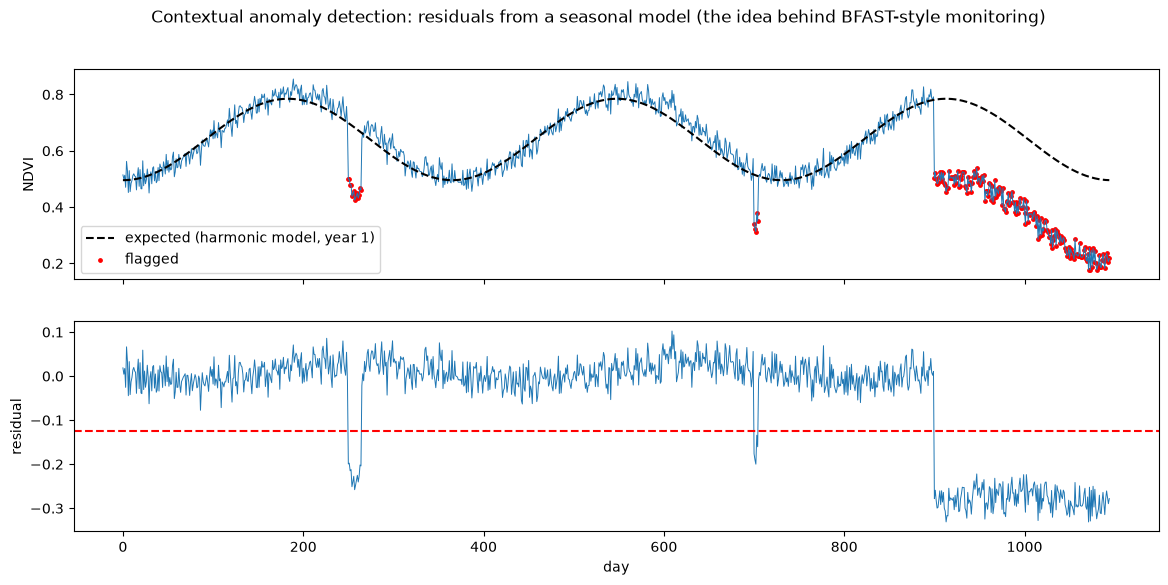

precision 1.000 | recall 1.000


In [7]:
days = np.arange(3 * 365)
seasonal = 0.65 + 0.15 * np.sin(2 * np.pi * (days - 100) / 365)
ndvi = seasonal + rng.normal(0, 0.025, len(days))
events = [(250, 265, -0.25), (700, 705, -0.18), (900, 1095, -0.30)]          # short drop, very short drop, deforestation (persistent)
truth = np.zeros(len(days), bool)
for a, b, d in events:
    ndvi[a:b] += d; truth[a:b] = True
t = days
design = np.c_[np.ones_like(t), np.sin(2 * np.pi * t / 365), np.cos(2 * np.pi * t / 365)]
train = days < 365                                                           # fit the expected season on a clean first year
coef = np.linalg.lstsq(design[train], ndvi[train], rcond=None)[0]
resid = ndvi - design @ coef
mad = np.median(np.abs(resid[train] - np.median(resid[train]))) * 1.4826
flag = resid < -4 * mad
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(days, ndvi, lw=0.7); axes[0].plot(days, design @ coef, "k--", label="expected (harmonic model, year 1)")
axes[0].scatter(days[flag], ndvi[flag], c="r", s=6, label="flagged"); axes[0].legend(); axes[0].set_ylabel("NDVI")
axes[1].plot(days, resid, lw=0.7); axes[1].axhline(-4 * mad, c="r", ls="--"); axes[1].set_ylabel("residual"); axes[1].set_xlabel("day")
plt.suptitle("Contextual anomaly detection: residuals from a seasonal model (the idea behind BFAST-style monitoring)"); plt.show()
print(f"precision {np.mean(truth[flag]):.3f} | recall {np.mean(flag[truth]):.3f}")

### An ensemble of detectors
Different detectors catch different anomalies. Rank-average their scores for robustness.

In [8]:
from scipy.stats import rankdata
score_list = [-EllipticEnvelope(random_state=0).fit(X).score_samples(X), score_iso, -LocalOutlierFactor(20).fit(X).negative_outlier_factor_,
              -OneClassSVM(nu=0.06, gamma=0.3).fit(X).score_samples(X)]
ens = np.mean([rankdata(s) for s in score_list], axis=0)
print(f"rank-averaged ensemble: ROC-AUC {roc_auc_score(y, ens):.3f} | PR-AUC {average_precision_score(y, ens):.3f}")

rank-averaged ensemble: ROC-AUC 0.942 | PR-AUC 0.844


## **Practice Problems**
1. Vary `n_neighbors` of LOF (5, 20, 50, 100). How does detection of the local anomalies change?
2. Add 8 irrelevant noise dimensions to `X`. Which detectors degrade most?
3. Use Isolation Forest in **novelty** mode: fit only on `normal`, then score new points.
4. *(Advanced)* Use a GMM (Day 48) as an anomaly detector on `X` (score = negative log-density). Compare its PR-AUC.

In [9]:
# Solution 1
for k in [5, 20, 50, 100]:
    lof = LocalOutlierFactor(k, contamination=0.06).fit(X); p_ = lof.fit_predict(X)
    print(f"k={k:>3}: PR-AUC {average_precision_score(y, -lof.negative_outlier_factor_):.3f} | local anomalies caught {np.mean(p_[-20:] == -1):.2f}")
# Solution 2
Xn = np.c_[X, rng.normal(size=(len(X), 8))]; Xn = StandardScaler().fit_transform(Xn)
for name, s in [("IsolationForest", -IsolationForest(random_state=0).fit(Xn).score_samples(Xn)), ("LOF", -LocalOutlierFactor(20).fit(Xn).negative_outlier_factor_),
                ("OneClassSVM", -OneClassSVM(nu=0.06, gamma="scale").fit(Xn).score_samples(Xn))]:
    print(f"{name:<16} PR-AUC with noise dims: {average_precision_score(y, s):.3f}")
# Solution 3
iso_nov = IsolationForest(random_state=0).fit(normal)
print("novelty mode PR-AUC:", round(average_precision_score(y, -iso_nov.score_samples(X)), 3))
# Solution 4
from sklearn.mixture import GaussianMixture
g = GaussianMixture(2, random_state=0).fit(X)
print("GMM density PR-AUC:", round(average_precision_score(y, -g.score_samples(X)), 3))

k=  5: PR-AUC 0.469 | local anomalies caught 0.60
k= 20: PR-AUC 0.842 | local anomalies caught 0.75
k= 50: PR-AUC 0.852 | local anomalies caught 0.70
k=100: PR-AUC 0.856 | local anomalies caught 0.70
IsolationForest  PR-AUC with noise dims: 0.182
LOF              PR-AUC with noise dims: 0.195
OneClassSVM      PR-AUC with noise dims: 0.118


novelty mode PR-AUC: 0.692
GMM density PR-AUC: 0.826


## **Key References**
- Chandola, V., Banerjee, A., & Kumar, V. (2009). Anomaly detection: A survey. *ACM Computing Surveys*, 41(3), 15.
- Liu, F. T., Ting, K. M., & Zhou, Z.-H. (2008). Isolation forest. *IEEE ICDM 2008*, 413-422.
- Breunig, M. M., Kriegel, H.-P., Ng, R. T., & Sander, J. (2000). LOF: Identifying density-based local outliers. *SIGMOD 2000*, 93-104.
- Scholkopf, B., Platt, J. C., Shawe-Taylor, J., Smola, A. J., & Williamson, R. C. (2001). Estimating the support of a high-dimensional distribution. *Neural Computation*, 13(7), 1443-1471.
- Rousseeuw, P. J. (1984). Least median of squares regression. *Journal of the American Statistical Association*, 79(388), 871-880.
- Verbesselt, J., Hyndman, R., Newnham, G., & Culvenor, D. (2010). Detecting trend and seasonal changes in satellite image time series. *Remote Sensing of Environment*, 114(1), 106-115.